# Dataset Validation: IndoNanoT5 MCQ Generation (v3)

**Purpose:** Audit & validate dataset against design guide

**Design Guide:** `docs/dataset/02-Dataset-Design-Guide.md`

**Dataset:** `dataset_aqg/dataset-task-v3/`

## 1. Setup & Import

In [1]:
import sys
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Add src to path
sys.path.append(str(Path.cwd().parent))
from dataset.dataset_validator import DatasetValidator

# Plotting config
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

print('✅ Imports successful')

✅ Imports successful


## 2. Initialize Validator & Set Paths

In [2]:
# Initialize validator
validator = DatasetValidator()

# IMPORTANT: Set root to dataset-task-v3 (NOT to subfolder!)
DATASET_ROOT = Path('../../dataset_aqg/dataset-task-v3')

print(f'📂 Dataset root: {DATASET_ROOT}')
print(f'📂 Exists: {DATASET_ROOT.exists()}')
print(f'📂 Absolute: {DATASET_ROOT.resolve()}')

# List available folders
if DATASET_ROOT.exists():
    folders = [f.name for f in DATASET_ROOT.iterdir() if f.is_dir()]
    print(f'\n📁 Available folders: {folders}')

📂 Dataset root: ..\..\dataset_aqg\dataset-task-v3
📂 Exists: True
📂 Absolute: D:\2-Project\AQG\dataset_aqg\dataset-task-v3

📁 Available folders: ['01-perkenalan-python', '02-berinteraksi-dengan-data', '03-ekspresi']


## 3. Mode Selection

**Choose validation mode:**
- `MODE = 'single'` → Validate one file
- `MODE = 'folder'` → Validate all files in a folder
- `MODE = 'all'` → Validate entire dataset

In [3]:
# ========================================
# CONFIGURATION: Change these values
# ========================================

MODE = 'folder'  # Options: 'single', 'folder', 'all'

# For MODE='single': specify file path
SINGLE_FILE = '01-perkenalan-python/01-perkenalan-python.jsonl'

# For MODE='folder': specify folder name
FOLDER_NAME = '01-perkenalan-python'

# ========================================
# Validation execution
# ========================================

if MODE == 'single':
    FILE_PATH = DATASET_ROOT / SINGLE_FILE
    print(f'🔍 Mode: Single file')
    print(f'📄 File: {FILE_PATH}')
    print(f'📄 Exists: {FILE_PATH.exists()}')
    
    if FILE_PATH.exists():
        result = validator.validate_file(str(FILE_PATH))
        results = [result]
    else:
        print('❌ File not found!')
        results = []

elif MODE == 'folder':
    FOLDER_PATH = DATASET_ROOT / FOLDER_NAME
    print(f'🔍 Mode: Folder validation')
    print(f'📁 Folder: {FOLDER_PATH}')
    print(f'📁 Exists: {FOLDER_PATH.exists()}')
    
    if FOLDER_PATH.exists():
        results = validator.validate_folder(str(FOLDER_PATH), recursive=True)
    else:
        print('❌ Folder not found!')
        results = []

elif MODE == 'all':
    print(f'🔍 Mode: Full dataset validation')
    print(f'📁 Root: {DATASET_ROOT}')
    results = validator.validate_folder(str(DATASET_ROOT), recursive=True)

else:
    print(f'❌ Invalid MODE: {MODE}')
    results = []

print(f'\n✅ Validation complete: {len(results)} files processed')

🔍 Mode: Folder validation
📁 Folder: ..\..\dataset_aqg\dataset-task-v3\01-perkenalan-python
📁 Exists: True
📂 Found 3 JSONL files
🔍 Validating...

  Validating: 01-perkenalan-python.jsonl... ⚠️  132 warnings
  Validating: 02-menjalankan-kode-program-pertama.jsonl... ⚠️  117 warnings
  Validating: 03-bersiap-membuat-kode-program-pertama-di-lokal.jsonl... ⚠️  125 warnings

✅ Validation complete: 3 files processed


## 4. Validation Report

In [4]:
if results:
    report = validator.generate_report(results)
    print(report)
else:
    print('⚠️ No files to report')

DATASET VALIDATION REPORT
IndoNanoT5 MCQ Generation - Dataset v3

📊 SUMMARY
--------------------------------------------------------------------------------
Total files validated: 3
Total samples: 344
Valid samples: 344 (100.0%)

🔴 Critical issues: 0
🟡 Warnings: 374
🔵 Minor issues: 0

📁 PER-FILE RESULTS
--------------------------------------------------------------------------------

✅ PASS 01-perkenalan-python.jsonl
  Samples: 110 | Valid: 110
  Issues: 🔴 0 | 🟡 132 | 🔵 0

✅ PASS 02-menjalankan-kode-program-pertama.jsonl
  Samples: 110 | Valid: 110
  Issues: 🔴 0 | 🟡 117 | 🔵 0

✅ PASS 03-bersiap-membuat-kode-program-pertama-di-lokal.jsonl
  Samples: 124 | Valid: 124
  Issues: 🔴 0 | 🟡 125 | 🔵 0



## 5. Issue Analysis

In [5]:
if not results:
    print('⚠️ No results to analyze')
else:
    all_issues = []
    for result in results:
        for issue in result.issues:
            all_issues.append({
                'file': Path(result.filepath).name,
                'severity': issue.severity,
                'category': issue.category,
                'message': issue.message,
                'line': issue.line_number
            })
    
    df_issues = pd.DataFrame(all_issues)
    
    if not df_issues.empty:
        print(f'📋 Total issues: {len(df_issues)}\n')
        print('By Severity:')
        print(df_issues['severity'].value_counts())
        print('\nBy Category:')
        print(df_issues['category'].value_counts())
        print('\nFirst 10 issues:')
        display(df_issues.head(10))
    else:
        print('✅ No issues found!')

📋 Total issues: 374

By Severity:
severity
WARNING    374
Name: count, dtype: int64

By Category:
category
CONTENT    344
QUALITY     30
Name: count, dtype: int64

First 10 issues:


,file,severity,category,message,line
0,01-perkenalan-python.jsonl,WARNING,CONTENT,Markdown formatting detected: _soal_,1.0
1,01-perkenalan-python.jsonl,WARNING,CONTENT,Markdown formatting detected: _soal_,2.0
2,01-perkenalan-python.jsonl,WARNING,CONTENT,Markdown formatting detected: _soal_,3.0
3,01-perkenalan-python.jsonl,WARNING,CONTENT,Markdown formatting detected: _soal_,4.0
4,01-perkenalan-python.jsonl,WARNING,CONTENT,Markdown formatting detected: _soal_,5.0
5,01-perkenalan-python.jsonl,WARNING,CONTENT,Markdown formatting detected: _soal_,6.0
6,01-perkenalan-python.jsonl,WARNING,CONTENT,Markdown formatting detected: _soal_,7.0
7,01-perkenalan-python.jsonl,WARNING,CONTENT,Markdown formatting detected: _soal_,8.0
8,01-perkenalan-python.jsonl,WARNING,CONTENT,Markdown formatting detected: _soal_,9.0
9,01-perkenalan-python.jsonl,WARNING,CONTENT,Markdown formatting detected: _soal_,10.0


## 6. Critical Issues

In [6]:
if results and not df_issues.empty:
    critical = df_issues[df_issues['severity'] == 'CRITICAL']
    if not critical.empty:
        print(f'🔴 CRITICAL: {len(critical)} issues\n')
        print('By type:')
        print(critical['message'].value_counts())
        print('\nAll critical issues:')
        display(critical)
    else:
        print('✅ No critical issues!')

✅ No critical issues!


## 7. Visualizations

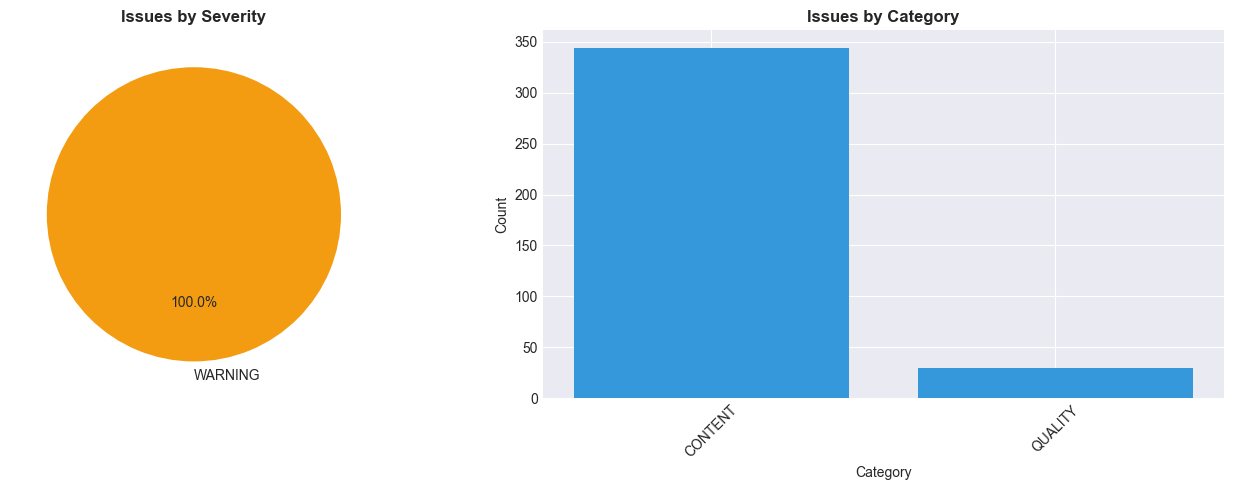

In [7]:
if results and not df_issues.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Pie: Severity
    severity_counts = df_issues['severity'].value_counts()
    colors = {'CRITICAL': '#e74c3c', 'WARNING': '#f39c12', 'MINOR': '#3498db'}
    pie_colors = [colors.get(s, '#95a5a6') for s in severity_counts.index]
    axes[0].pie(severity_counts.values, labels=severity_counts.index, 
                autopct='%1.1f%%', colors=pie_colors, startangle=90)
    axes[0].set_title('Issues by Severity', fontweight='bold')
    
    # Bar: Category
    category_counts = df_issues['category'].value_counts()
    axes[1].bar(category_counts.index, category_counts.values, color='#3498db')
    axes[1].set_title('Issues by Category', fontweight='bold')
    axes[1].set_xlabel('Category')
    axes[1].set_ylabel('Count')
    axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
else:
    print('⚠️ No data to visualize')

## 8. Length Distribution

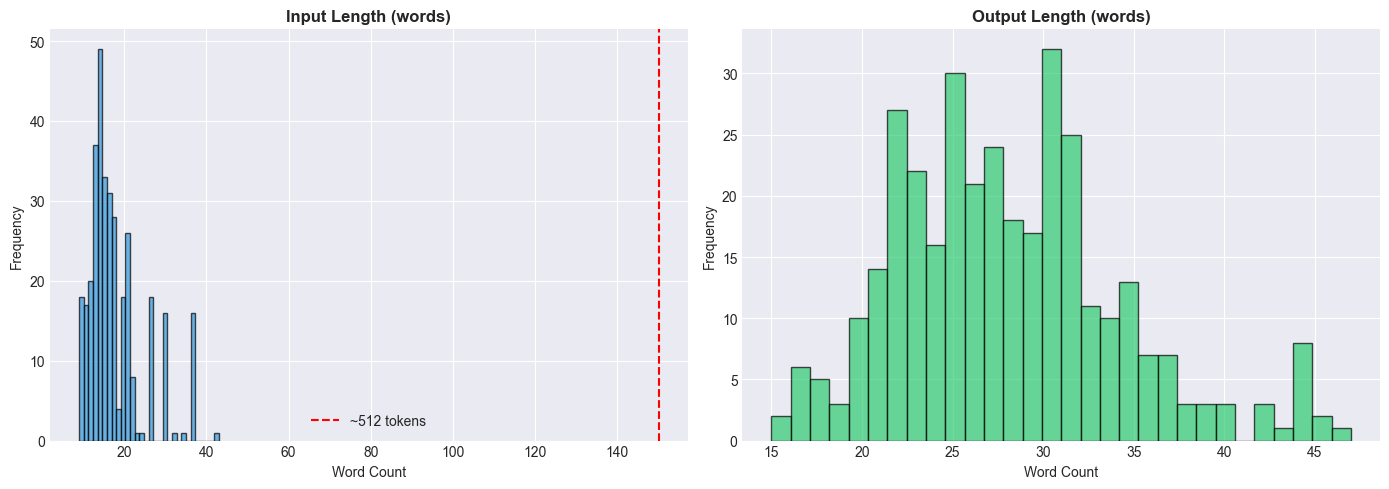


📊 Statistics:
  Input: min=9, max=43, avg=17.8
  Output: min=15, max=47, avg=28.0


In [8]:
if not results:
    print('⚠️ No results')
else:
    all_input_lengths = []
    all_output_lengths = []
    
    for result in results:
        try:
            with open(result.filepath, 'r', encoding='utf-8') as f:
                for line in f:
                    if not line.strip():
                        continue
                    try:
                        sample = json.loads(line)
                        if 'input' in sample:
                            all_input_lengths.append(len(sample['input'].split()))
                        if 'output' in sample:
                            all_output_lengths.append(len(sample['output'].split()))
                    except:
                        pass
        except:
            pass
    
    if all_input_lengths and all_output_lengths:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        axes[0].hist(all_input_lengths, bins=30, color='#3498db', edgecolor='black', alpha=0.7)
        axes[0].axvline(x=150, color='red', linestyle='--', label='~512 tokens')
        axes[0].set_title('Input Length (words)', fontweight='bold')
        axes[0].set_xlabel('Word Count')
        axes[0].set_ylabel('Frequency')
        axes[0].legend()
        
        axes[1].hist(all_output_lengths, bins=30, color='#2ecc71', edgecolor='black', alpha=0.7)
        axes[1].set_title('Output Length (words)', fontweight='bold')
        axes[1].set_xlabel('Word Count')
        axes[1].set_ylabel('Frequency')
        
        plt.tight_layout()
        plt.show()
        
        print(f'\n📊 Statistics:')
        print(f'  Input: min={min(all_input_lengths)}, max={max(all_input_lengths)}, avg={sum(all_input_lengths)/len(all_input_lengths):.1f}')
        print(f'  Output: min={min(all_output_lengths)}, max={max(all_output_lengths)}, avg={sum(all_output_lengths)/len(all_output_lengths):.1f}')
    else:
        print('⚠️ No length data')

## 9. Samples per File

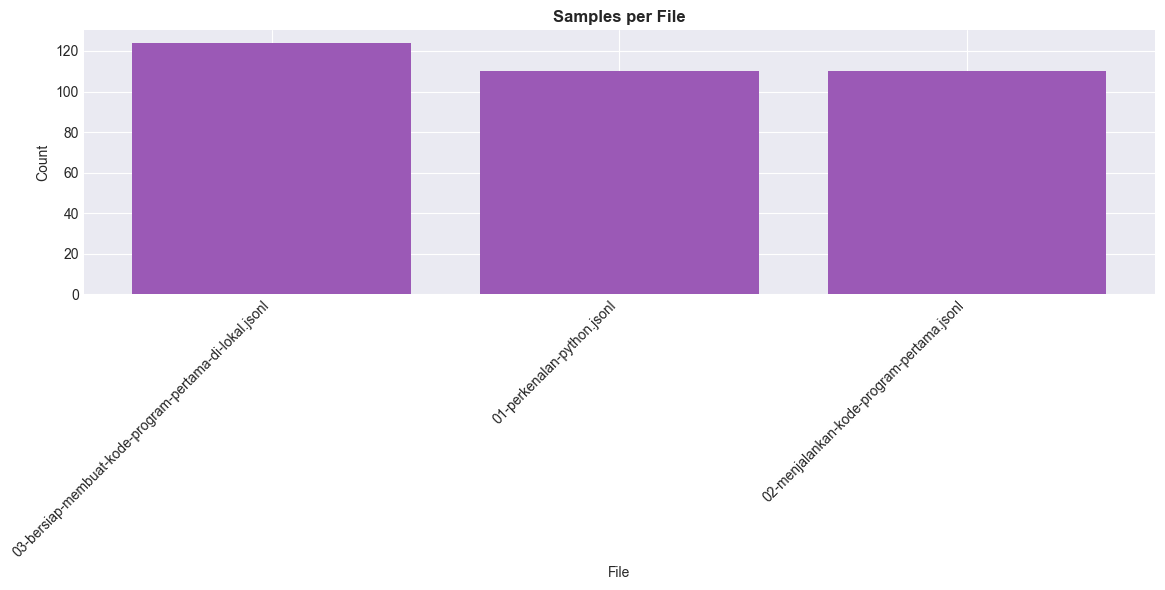

In [9]:
if results:
    file_samples = [(Path(r.filepath).name, r.total_samples) for r in results]
    file_samples.sort(key=lambda x: x[1], reverse=True)
    
    files, counts = zip(*file_samples)
    
    plt.figure(figsize=(12, 6))
    plt.bar(range(len(files)), counts, color='#9b59b6')
    plt.xticks(range(len(files)), files, rotation=45, ha='right')
    plt.title('Samples per File', fontweight='bold')
    plt.xlabel('File')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()
else:
    print('⚠️ No results')

## 10. Sample Inspection

In [10]:
if results:
    first_file = results[0].filepath
    print(f'📄 File: {Path(first_file).name}')
    print('='*80)
    
    with open(first_file, 'r', encoding='utf-8') as f:
        samples = [json.loads(line) for line in f if line.strip()]
    
    for i, sample in enumerate(samples[:3], 1):
        print(f'\n--- Sample {i} ---')
        inp = sample.get('input', 'N/A')
        print(f'INPUT: {inp[:150]}...' if len(inp) > 150 else f'INPUT: {inp}')
        print(f'OUTPUT: {sample.get("output", "N/A")}')
        print('-' * 80)
else:
    print('⚠️ No results')

📄 File: 01-perkenalan-python.jsonl

--- Sample 1 ---
INPUT: buat_soal_pilihan_ganda: Python adalah bahasa pemrograman multifungsi yang dirilis pada tahun 1991 oleh Guido van Rossum (GvR).
OUTPUT: question: Dari penjelasan di atas, Tahun berapakah bahasa pemrograman Python pertama kali dirilis?
answer: 1991
distractors: 1995 | 1989 | 2000
--------------------------------------------------------------------------------

--- Sample 2 ---
INPUT: buat_soal_pilihan_ganda: Guido van Rossum membuat Python sebagai bahasa pemrograman yang mudah dibaca dan dimengerti (readable) serta memiliki kemampu...
OUTPUT: question: Dari penjelasan di atas, Apa salah satu fokus utama Guido van Rossum saat menciptakan Python?
answer: Kemudahan pembacaan kode (readability)
distractors: Penggunaan memori manual | Sintaksis yang sangat kompleks | Kecepatan eksekusi maksimal
--------------------------------------------------------------------------------

--- Sample 3 ---
INPUT: buat_soal_pilihan_ganda: Python ti

## 11. Actionable Checklist

In [11]:
print('📋 ACTIONABLE CHECKLIST')
print('='*80)

if results and not df_issues.empty:
    critical = df_issues[df_issues['severity'] == 'CRITICAL']
    if not critical.empty:
        print('\n🔴 CRITICAL (Must Fix):')
        for msg, count in critical['message'].value_counts().items():
            print(f'  [ ] Fix {count}x: {msg}')
    
    warnings = df_issues[df_issues['severity'] == 'WARNING']
    if not warnings.empty:
        print('\n🟡 WARNINGS (Should Fix):')
        for msg, count in warnings['message'].value_counts().items():
            print(f'  [ ] Review {count}x: {msg}')
else:
    print('\n✅ No issues!')

print('\n' + '='*80)

📋 ACTIONABLE CHECKLIST

🟡 WARNINGS (Should Fix):
  [ ] Review 344x: Markdown formatting detected: _soal_
  [ ] Review 10x: Duplicate input found 7 times
  [ ] Review 8x: Input very short (9 words)
  [ ] Review 6x: Duplicate input found 16 times
  [ ] Review 5x: Duplicate input found 8 times
  [ ] Review 1x: Duplicate input found 14 times



## 12. Export Results

In [12]:
if results:
    export_data = validator.export_issues_to_dict(results)
    
    output_path = Path('validation_report_v3.json')
    with open(output_path, 'w', encoding='utf-8') as f:
        json.dump(export_data, f, indent=2, ensure_ascii=False)
    
    print(f'✅ Exported to: {output_path}')
    print(f'\n📊 Summary:')
    print(f'  Files: {export_data["summary"]["total_files"]}')
    print(f'  Samples: {export_data["summary"]["total_samples"]}')
    print(f'  Valid: {export_data["summary"]["valid_samples"]}')
    print(f'  Critical: {export_data["summary"]["critical_count"]}')
    print(f'  Warnings: {export_data["summary"]["warning_count"]}')
else:
    print('⚠️ No results to export')

✅ Exported to: validation_report_v3.json

📊 Summary:
  Files: 3
  Samples: 344
  Valid: 344
  Critical: 0
  Warnings: 374
